<a href="https://colab.research.google.com/github/edusalman345/Netflix-Trend-Analysis/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


**Netflix Dataset**
**<h4>What can i get form this dataset</h4>**
<ul><li>What are the most popular genres on Netflix?</li>
<li>Is Netflix focused more on Movies or TV Shows?</li>
<li>Which countries produce the most content?</li>
<li>How has content grown over time?</li>
<li>What type of content gets added more recently?</li>
</ul>

In [77]:
df = pd.read_csv('/content/netflix_titles.csv')

In [78]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [79]:
df.shape

(8807, 12)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [81]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Missing Data**
<ul>
<li>Director = 2634</li>
<li>Cast = 825</li>
<li>Country = 831</li>
<li>date_added = 10</li>
<li>rating = 4</li>
<li>duration = 3</li>
</ul>

In [82]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [84]:
df['date_added'] =  pd.to_datetime(df['date_added'], errors='coerce')
df['release_year'] = df['date_added'].dt.year

/tmp/ipykernel_539/2678051418.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] =  pd.to_datetime(df['date_added'], errors='coerce')


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   float64       
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(10)
memory usage: 825.8+ KB


In [86]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2021.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [87]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


**Types of content Netflix deals with according to current dataset:**
<ul>
<li>Movies - 6131</li>
<li>TV Shows - 2676</li>
</ul>

After seeing the numbers it is assumed that Nexflix is a platfrom which focuses on Movies more then TV Shows

In [92]:
genres = df['listed_in'].str.split(',').explode()
genres = genres[genres != 'Unknown']
genres = genres[genres != '']
genres = genres.str.strip()
genres = genres.str.strip()
top_genres = genres.value_counts().head(10)
top_genres
top_genres.to_csv('top_genres.csv')

**Top 10 Genres and Issue**
Issue:
While finidng top genres a issue or a error occured, It was causing confussion by showing to fileds of Dramas genre
so i check if there are extra spaces in genre and python taking them two completly different strings
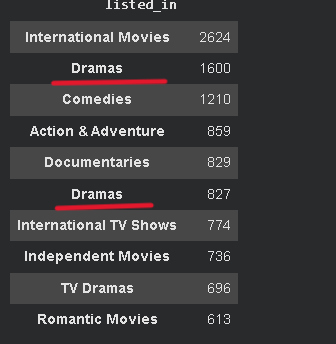

In [89]:
countries = df['country'].str.split(', ').explode()
countries = countries.str.strip()
top_countries = countries.value_counts().head(10)
top_countries


,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


In [90]:
df['date_added'].value_counts().sort_index()

,count
date_added,
2008-01-01,1
2008-02-04,1
2009-05-05,1
2009-11-18,1
2010-11-01,1
...,...
2021-09-21,5
2021-09-22,9
2021-09-23,2


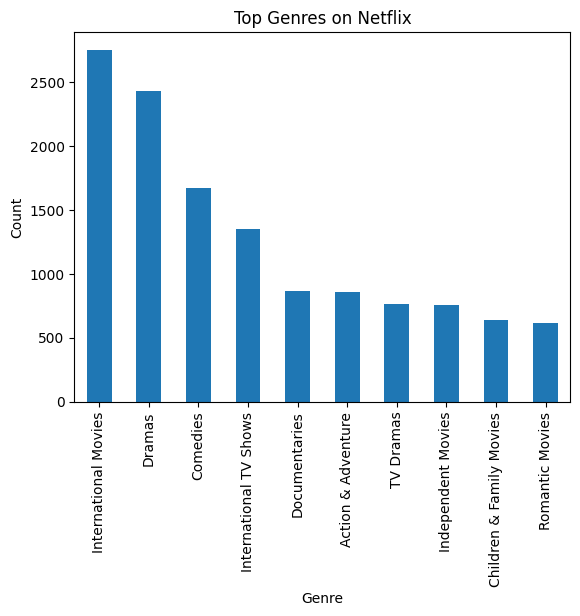

In [91]:
top_genres.plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
# plt.xticks(rotation=45)
plt.show()

**📊 Analyze Netflix Dataset**

The Netflix dataset was examined to understand the type of content available on the platform. By organizing and cleaning the data, we were able to identify patterns in movies and TV shows, such as the most common genres and overall content distribution.

**🎭 Find Top Genres**

After processing the data, the most frequent genres were identified.
It was found that:

International Movies and Dramas are the most dominant categories
Comedies are also highly popular
Other genres like Documentaries and Action & Adventure appear regularly but in smaller numbers

This shows that Netflix focuses heavily on global and story-driven content.

**📈 Visualize Trends**

The data was presented using a bar chart to make the insights easy to understand.
The visualization clearly shows:

A strong lead of top genres (especially International content)
A gradual decline across other categories
A wide variety of content available on the platform

